<a href="https://colab.research.google.com/github/ignaciomorenobarria21-a11y/Machine_Learning/blob/main/Copia_de_Sesion_06_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Fundamentos de Machine Learning

## Sesión 6: Ensamblado de Árboles (Random Forest)

**Máster en Formación Permanente en Inteligencia Artificial para el Sector Financiero**  
Universidad Internacional de Valencia · Edición Octubre 2025/26

---

📅 **Fecha:** 27 de enero de 2026  
⏱️ **Duración:** ~100 minutos  
👨‍🏫 **Profesor:** Jaume Antolí Plaza

## 1. Introducción: ¿Por qué Ensamblar Modelos?

En la sesión anterior vimos que un **árbol de decisión individual** tiene un problema:

```
EL PROBLEMA DEL ÁRBOL INDIVIDUAL
═══════════════════════════════════════════════════════════════════

    📊 Datos originales          📊 Datos ligeramente diferentes
    ─────────────────────        ─────────────────────────────────

         ¿RSI > 65?                      ¿Stoch > 45?
         /        \                      /          \
       Sí          No                  Sí            No
       ↓            ↓                  ↓              ↓
    ¿CCI>100?    SUBE              ¿RSI>70?       BAJA
     /    \                         /    \
   BAJA  SUBE                    BAJA   SUBE

    → Pequeños cambios en los datos pueden generar
      árboles COMPLETAMENTE diferentes.

    → Esto se llama ALTA VARIANZA.
```

### La Solución: "Sabiduría de la Multitud"

```
ANALOGÍA: DIAGNÓSTICO MÉDICO
═══════════════════════════════════════════════════════════════════

    UN SOLO MÉDICO                    JUNTA MÉDICA (5 especialistas)
    ──────────────                    ────────────────────────────────

         👨‍⚕️                              👨‍⚕️ 👩‍⚕️ 👨‍⚕️ 👩‍⚕️ 👨‍⚕️
          │                                │  │  │  │  │
          ↓                                ↓  ↓  ↓  ↓  ↓
      "GRIPE"                          "GRIPE" "GRIPE" "COVID" "GRIPE" "GRIPE"
                                              │
                                              ↓
                                         VOTACIÓN
                                              │
                                              ↓
                                     Diagnóstico: GRIPE (4 de 5)

    → Si un médico se equivoca,       → Si un médico se equivoca,
      el paciente sufre.                la mayoría lo corrige.

    → Alta dependencia de              → Decisión más ROBUSTA
      un solo criterio                   y CONFIABLE
```

### El Principio del Ensemble

```
ENSEMBLE = COMBINAR MÚLTIPLES MODELOS
═══════════════════════════════════════════════════════════════════

                    ┌─────────┐
                    │  Datos  │
                    └────┬────┘
                         │
         ┌───────────────┼───────────────┐
         ↓               ↓               ↓
    ┌─────────┐     ┌─────────┐     ┌─────────┐
    │ Árbol 1 │     │ Árbol 2 │     │ Árbol N │
    └────┬────┘     └────┬────┘     └────┬────┘
         │               │               │
         ↓               ↓               ↓
       SUBE            BAJA            SUBE       ... (N predicciones)
         │               │               │
         └───────────────┼───────────────┘
                         ↓
                   ┌───────────┐
                   │ VOTACIÓN  │
                   └─────┬─────┘
                         ↓
                  Predicción: SUBE
                  (mayoría simple)

    ✅ Combinar modelos "débiles" → Modelo "fuerte"
    ✅ Los errores individuales se cancelan
    ✅ Menor varianza, predicciones más estables
```

## 2. Bagging: Bootstrap Aggregating

**Bagging** es la técnica base de Random Forest. Consiste en:

1. Crear **múltiples muestras** de los datos (con reemplazo)
2. Entrenar **un árbol diferente** con cada muestra
3. **Combinar** las predicciones (votación)

```
BOOTSTRAP: MUESTREO CON REEMPLAZO
═══════════════════════════════════════════════════════════════════

Datos originales (N=10):

    [A] [B] [C] [D] [E] [F] [G] [H] [I] [J]


Muestra Bootstrap 1 (N=10, CON reemplazo):

    [A] [A] [C] [C] [E] [F] [F] [H] [I] [J]
     ↑       ↑       ↑
     │       │       └── F aparece 2 veces
     │       └────────── C aparece 2 veces
     └────────────────── A aparece 2 veces
                         B, D, G NO aparecen


Muestra Bootstrap 2 (N=10, CON reemplazo):

    [B] [B] [D] [E] [E] [E] [G] [H] [J] [J]


Muestra Bootstrap 3 (N=10, CON reemplazo):

    [A] [C] [D] [D] [F] [G] [G] [G] [I] [J]


→ Cada muestra tiene el MISMO tamaño pero diferentes observaciones.
→ Aproximadamente 63% de los datos originales aparecen en cada muestra.
→ El 37% restante son los datos "Out-of-Bag" (OOB) - ¡útil para evaluar!
```

### ¿Por qué funciona?

```
DIVERSIDAD → ROBUSTEZ
═══════════════════════════════════════════════════════════════════

    Árbol 1 (entrena con muestra 1)
    ───────────────────────────────
    → Ve muchos ejemplos de tipo A, C, F
    → Aprende patrones específicos de estos


    Árbol 2 (entrena con muestra 2)
    ───────────────────────────────
    → Ve muchos ejemplos de tipo B, E
    → Aprende patrones DIFERENTES


    Árbol 3 (entrena con muestra 3)
    ───────────────────────────────
    → Ve muchos ejemplos de tipo D, G
    → Aprende OTROS patrones


    COMBINACIÓN (votación)
    ──────────────────────
    → Cada árbol "se especializa" en diferentes aspectos
    → Los errores de uno son compensados por otros
    → El resultado es más GENERALIZABLE
```

## 3. Random Forest = Bagging + Aleatoriedad en Features

**Random Forest** añade una capa extra de aleatoriedad: en cada split, solo considera un **subconjunto aleatorio de features**.

```
BAGGING vs RANDOM FOREST
═══════════════════════════════════════════════════════════════════

BAGGING (solo datos aleatorios):
──────────────────────────────────

    En cada split, el árbol puede elegir entre TODAS las features:

    Features disponibles: [RSI, Stoch, WILLR, CCI]
                           ↓    ↓      ↓     ↓
                          Elige la MEJOR de las 4

    → Problema: Si RSI es muy buena, TODOS los árboles
      empezarán con RSI → árboles muy SIMILARES


RANDOM FOREST (datos + features aleatorios):
────────────────────────────────────────────

    En cada split, solo considera un SUBCONJUNTO aleatorio:

    Árbol 1, Split 1:  [RSI, CCI]      → Elige RSI
    Árbol 1, Split 2:  [Stoch, WILLR]  → Elige Stoch

    Árbol 2, Split 1:  [Stoch, CCI]    → Elige CCI
    Árbol 2, Split 2:  [RSI, WILLR]    → Elige WILLR

    → Resultado: árboles mucho más DIVERSOS
    → Cada árbol explora diferentes combinaciones
```

### El Parámetro max_features

```
max_features: ¿CUÁNTAS FEATURES CONSIDERAR EN CADA SPLIT?
═══════════════════════════════════════════════════════════════════

    max_features = 'sqrt'  (por defecto en clasificación)
    ─────────────────────
    Si tenemos 4 features: √4 = 2 features por split

    max_features = 'log2'
    ─────────────────────
    Si tenemos 4 features: log₂(4) = 2 features por split

    max_features = None (todas)
    ──────────────────────────
    Usa todas las features → equivale a Bagging puro


    TRADE-OFF:
    ──────────
    • max_features BAJO  → Árboles más diversos, individualmente peores
    • max_features ALTO  → Árboles más similares, individualmente mejores

    → El punto óptimo suele estar en 'sqrt' o 'log2'
```

## 4. Cargar Librerías

In [ ]:
# ============================================================
# LIBRERÍAS NECESARIAS
# ============================================================

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Suprimir warnings
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 20)

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


## 5. Cargar Datos EUR/USD

Utilizamos el mismo dataset de las sesiones anteriores para mantener la consistencia.

In [ ]:
# ============================================================
# CARGA DE DATOS
# Dataset preparado en la Sesión 1 con indicadores técnicos
# ============================================================

# Cargar el dataset directamente desde Google Drive
url = 'https://drive.google.com/uc?id=13vNdqTBl4xZurr1jbcoVHCy9PinJosiL'
df = pd.read_csv(url, index_col=0, parse_dates=True)

print(f"Dataset cargado: {len(df):,} filas")
print(f"Período: {df.index[0].strftime('%Y-%m-%d')} a {df.index[-1].strftime('%Y-%m-%d')}")
print(f"Columnas totales: {len(df.columns)}")
df.head()

Dataset cargado: 2,489 filas
Período: 2010-05-25 a 2019-12-30
Columnas totales: 501


,Open,High,Low,Close,RSI_2,STOCH_2,WILLR_2,CCI_2,ADX_2,RSI_3,...,WILLR_99,CCI_99,ADX_99,RSI_100,STOCH_100,WILLR_100,CCI_100,ADX_100,Target_Return,Target_Direccion
Date,,,,,,,,,,,,,,,,,,,,,
2010-05-25,1.23684,1.23715,1.21747,1.23423,24.421350,41.330435,-57.244898,-12631.780092,58.297675,33.900535,...,-91.817137,-2434.608816,7.508539,27.285877,11.662837,-91.817137,-2415.491160,5.800495,-0.013466,0
2010-05-26,1.23454,1.23870,1.21651,1.21761,8.540825,18.673390,-95.042812,-30614.995315,55.630696,18.773705,...,-98.637557,-2373.603625,7.537198,26.645143,6.291037,-98.637557,-2357.164021,5.842580,0.015128,1
2010-05-27,1.21776,1.23936,1.21498,1.23603,62.538188,44.684518,-13.658737,-27969.102260,58.252217,53.366665,...,-91.078464,-2322.459890,7.568027,28.524123,6.155614,-91.078464,-2306.098927,5.886673,-0.007330,0
2010-05-28,1.23585,1.24518,1.22614,1.22697,39.561528,43.666813,-60.298013,-62192.874981,43.837486,40.607390,...,-94.796454,-2278.999465,7.587006,28.165683,5.162508,-94.796454,-2260.232794,5.919011,0.002812,1
2010-05-31,1.22748,1.23335,1.22568,1.23042,52.775417,50.116981,-75.692308,-55713.249821,31.356454,47.743744,...,-93.380663,-2233.290788,7.606547,28.511223,6.914806,-93.380663,-2215.977269,5.951770,-0.006250,0


## 6. Seleccionar Features

Usamos las mismas 4 features que en las sesiones anteriores (los indicadores direccionales con mejor correlación).

In [ ]:
# ============================================================
# SELECCIONAR FEATURES (IGUAL QUE SESIONES ANTERIORES)
# ============================================================

# Eliminar filas con valores NaN
df_clean = df.dropna()

# Indicadores direccionales
indicadores_direccionales = ['RSI', 'STOCH', 'WILLR', 'CCI']

# Encontrar el mejor periodo para cada indicador
mejores_features = []

print("Seleccionando el mejor periodo por indicador:")
print("=" * 55)

for indicador in indicadores_direccionales:
    mejor_corr = 0
    mejor_periodo = 2

    for periodo in range(2, 101):
        col_name = f"{indicador}_{periodo}"
        if col_name in df_clean.columns:
            corr = abs(df_clean[col_name].corr(df_clean['Target_Return']))
            if corr > mejor_corr:
                mejor_corr = corr
                mejor_periodo = periodo

    mejor_col = f"{indicador}_{mejor_periodo}"
    mejores_features.append(mejor_col)
    corr_real = df_clean[mejor_col].corr(df_clean['Target_Return'])
    print(f"  {indicador:8} → Periodo {mejor_periodo:3}  (correlación: {corr_real:+.4f})")

print("=" * 55)
print(f"\nFeatures seleccionadas: {mejores_features}")

Seleccionando el mejor periodo por indicador:
  RSI      → Periodo   2  (correlación: -0.0177)
  STOCH    → Periodo  15  (correlación: -0.0194)
  WILLR    → Periodo  16  (correlación: -0.0189)
  CCI      → Periodo  53  (correlación: +0.0177)

Features seleccionadas: ['RSI_2', 'STOCH_15', 'WILLR_16', 'CCI_53']


## 7. Preparar los Datos

In [ ]:
# ============================================================
# PREPARAR MATRICES X e y
# ============================================================

# Features (X) y Target (y)
X = df_clean[mejores_features]
y = df_clean['Target_Direccion']

print(f"📐 Dimensiones de los datos:")
print(f"   X (features): {X.shape}")
print(f"   y (target):   {y.shape}")
print(f"\n   Features: {list(X.columns)}")

📐 Dimensiones de los datos:
   X (features): (2489, 4)
   y (target):   (2489,)

   Features: ['RSI_2', 'STOCH_15', 'WILLR_16', 'CCI_53']


## 8. Entrenar Random Forest

Ahora entrenamos un Random Forest usando scikit-learn.

In [ ]:
# ============================================================
# ENTRENAR RANDOM FOREST
# ============================================================

# Crear y entrenar el modelo
rf = RandomForestClassifier(
    n_estimators=100,      # Número de árboles
    max_depth=4,           # Profundidad máxima (igual que árbol individual)
    max_features='sqrt',   # Features a considerar en cada split
    oob_score=True,        # Calcular OOB score (evaluación "gratis")
    random_state=42,       # Reproducibilidad
    n_jobs=-1              # Usar todos los cores
)

# Entrenar
rf.fit(X, y)

print("✅ Random Forest entrenado")
print("\n" + "=" * 55)
print("PARÁMETROS DEL MODELO")
print("=" * 55)
print(f"   n_estimators:  {rf.n_estimators} árboles")
print(f"   max_depth:     {rf.max_depth} niveles")
print(f"   max_features:  {rf.max_features} (√4 = 2 features por split)")
print(f"   oob_score:     {rf.oob_score}")

✅ Random Forest entrenado

PARÁMETROS DEL MODELO
   n_estimators:  100 árboles
   max_depth:     4 niveles
   max_features:  sqrt (√4 = 2 features por split)
   oob_score:     True


### Explicación de los Parámetros

```
PARÁMETROS CLAVE DE RANDOM FOREST
═══════════════════════════════════════════════════════════════════

n_estimators = 100
──────────────────
    Número de árboles en el bosque.
    • Más árboles → Predicción más estable (pero más lento)
    • Típicamente: 100-500 es suficiente
    • NO hay sobreajuste por usar muchos árboles


max_depth = 4
─────────────
    Profundidad máxima de cada árbol.
    • Igual que en árbol individual
    • Controla la complejidad de cada árbol


max_features = 'sqrt'
─────────────────────
    Features a considerar en cada split.
    • 'sqrt': √n_features (por defecto clasificación)
    • 'log2': log₂(n_features)
    • Con 4 features: 'sqrt' → 2 features por split


oob_score = True
────────────────
    Calcular "Out-of-Bag" score.
    • Cada árbol no ve ~37% de los datos
    • Podemos usar esos datos para evaluar
    • ¡Evaluación "gratis" sin partir datos!
```

## 9. Evaluar el Modelo

In [ ]:
# ============================================================
# EVALUAR RANDOM FOREST
# ============================================================

# Predicciones
y_pred_rf = rf.predict(X)

# Accuracy en entrenamiento
acc_train = accuracy_score(y, y_pred_rf)

# OOB Score (estimación de accuracy en datos "no vistos")
acc_oob = rf.oob_score_

# Matriz de confusión
cm = confusion_matrix(y, y_pred_rf)
vn, fp, fn, vp = cm.ravel()

print("=" * 60)
print("EVALUACIÓN DEL RANDOM FOREST")
print("=" * 60)
print(f"\n🎯 ACCURACY (Entrenamiento): {acc_train:.2%}")
print(f"🎯 ACCURACY (OOB Score):     {acc_oob:.2%}")
print("\n" + "=" * 60)
print("MATRIZ DE CONFUSIÓN")
print("=" * 60)
print(f"\n                    PREDICCIÓN")
print(f"                  BAJA      SUBE")
print(f"              ┌──────────┬──────────┐")
print(f"       BAJA   │  {vn:>5}   │  {fp:>5}   │")
print(f"REAL          │   (VN)   │   (FP)   │")
print(f"              ├──────────┼──────────┤")
print(f"       SUBE   │  {fn:>5}   │  {vp:>5}   │")
print(f"              │   (FN)   │   (VP)   │")
print(f"              └──────────┴──────────┘")

EVALUACIÓN DEL RANDOM FOREST

🎯 ACCURACY (Entrenamiento): 61.87%
🎯 ACCURACY (OOB Score):     51.79%

MATRIZ DE CONFUSIÓN

                    PREDICCIÓN
                  BAJA      SUBE
              ┌──────────┬──────────┐
       BAJA   │    555   │    682   │
REAL          │   (VN)   │   (FP)   │
              ├──────────┼──────────┤
       SUBE   │    267   │    985   │
              │   (FN)   │   (VP)   │
              └──────────┴──────────┘


In [ ]:
# ============================================================
# EXPLICAR OOB SCORE
# ============================================================

print("\n" + "=" * 60)
print("💡 ¿QUÉ ES EL OOB SCORE?")
print("=" * 60)
print("""
Out-of-Bag (OOB) Score:
───────────────────────

• Cada árbol se entrena con ~63% de los datos (bootstrap)
• El ~37% restante NO lo ve durante entrenamiento
• Podemos usar ese 37% para evaluar ESE árbol
• El OOB score es el promedio de estas evaluaciones

┌─────────────────────────────────────────────────────────┐
│  Árbol 1: Entrena con [A,C,D,F,G] → Evalúa con [B,E,H] │
│  Árbol 2: Entrena con [B,C,E,F,H] → Evalúa con [A,D,G] │
│  Árbol 3: Entrena con [A,B,D,E,G] → Evalúa con [C,F,H] │
│                    ...                                  │
│  OOB Score = Promedio de evaluaciones                   │
└─────────────────────────────────────────────────────────┘

Ventaja: ¡Evaluación "gratis" sin necesidad de partir datos!
""")

print(f"\n   OOB Score obtenido: {acc_oob:.2%}")
print(f"   → Estimación de accuracy en datos nuevos")
print("\n   ⚠️ En Sesión 8 aprenderemos partición IS/OOS más rigurosa.")


💡 ¿QUÉ ES EL OOB SCORE?

Out-of-Bag (OOB) Score:
───────────────────────

• Cada árbol se entrena con ~63% de los datos (bootstrap)
• El ~37% restante NO lo ve durante entrenamiento
• Podemos usar ese 37% para evaluar ESE árbol
• El OOB score es el promedio de estas evaluaciones

┌─────────────────────────────────────────────────────────┐
│  Árbol 1: Entrena con [A,C,D,F,G] → Evalúa con [B,E,H] │
│  Árbol 2: Entrena con [B,C,E,F,H] → Evalúa con [A,D,G] │
│  Árbol 3: Entrena con [A,B,D,E,G] → Evalúa con [C,F,H] │
│                    ...                                  │
│  OOB Score = Promedio de evaluaciones                   │
└─────────────────────────────────────────────────────────┘

Ventaja: ¡Evaluación "gratis" sin necesidad de partir datos!


   OOB Score obtenido: 51.79%
   → Estimación de accuracy en datos nuevos

   ⚠️ En Sesión 8 aprenderemos partición IS/OOS más rigurosa.


## 10. Importancia de las Variables (Feature Importance)

Random Forest nos dice qué variables son más importantes para la predicción.

In [ ]:
# ============================================================
# IMPORTANCIA DE VARIABLES
# ============================================================

# Obtener importancias
importances = pd.DataFrame({
    'Feature': mejores_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("=" * 55)
print("IMPORTANCIA DE VARIABLES (RANDOM FOREST)")
print("=" * 55)
print()

for _, row in importances.iterrows():
    barras = "█" * int(row['Importance'] * 50)
    print(f"   {row['Feature']:<12} │ {barras} {row['Importance']:.1%}")

print("\n" + "=" * 55)

IMPORTANCIA DE VARIABLES (RANDOM FOREST)

   RSI_2        │ █████████████████ 35.8%
   CCI_53       │ ███████████ 23.5%
   STOCH_15     │ ██████████ 21.0%
   WILLR_16     │ █████████ 19.7%



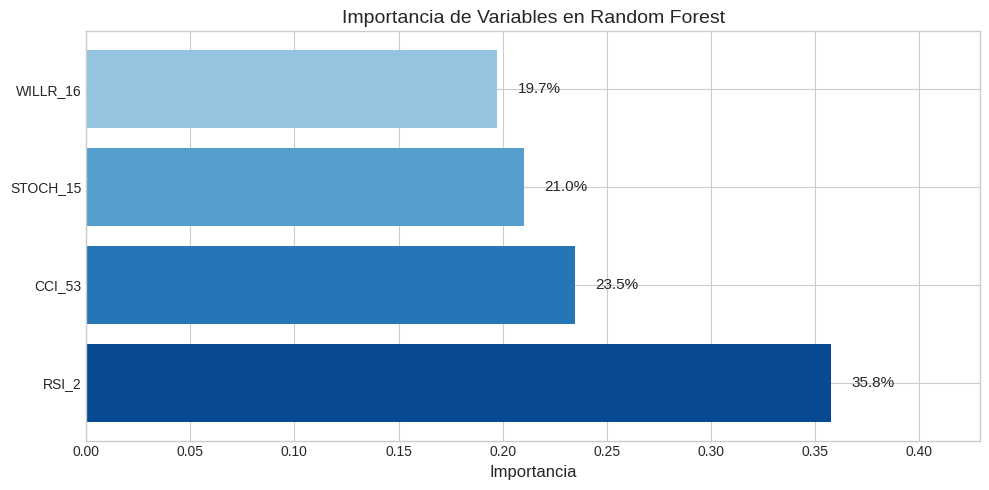


💡 La importancia en RF es más ESTABLE que en un árbol individual
   porque promedia la importancia de 100 árboles diferentes.


In [ ]:
# ============================================================
# VISUALIZAR IMPORTANCIA DE VARIABLES
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

# Colores por importancia
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(importances)))

# Barras
bars = ax.barh(importances['Feature'], importances['Importance'], color=colors[::-1])

# Etiquetas
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title('Importancia de Variables en Random Forest', fontsize=14)

# Añadir valores
for bar, imp in zip(bars, importances['Importance']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{imp:.1%}', va='center', fontsize=11)

ax.set_xlim(0, max(importances['Importance']) * 1.2)
plt.tight_layout()
plt.show()

print("\n💡 La importancia en RF es más ESTABLE que en un árbol individual")
print("   porque promedia la importancia de 100 árboles diferentes.")

## 11. Efecto del Número de Árboles (n_estimators)

In [ ]:
# ============================================================
# EFECTO DEL NÚMERO DE ÁRBOLES
# ============================================================

n_arboles_lista = [1, 5, 10, 20, 50, 100, 200, 500]
oob_scores = []
train_scores = []

print("Evaluando diferentes números de árboles...\n")
print(f"{'n_estimators':<15} {'Acc Train':<12} {'OOB Score':<12}")
print("-" * 40)

for n in n_arboles_lista:
    rf_temp = RandomForestClassifier(
        n_estimators=n,
        max_depth=4,
        max_features='sqrt',
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )
    rf_temp.fit(X, y)

    train_acc = accuracy_score(y, rf_temp.predict(X))
    train_scores.append(train_acc)
    oob_scores.append(rf_temp.oob_score_)

    print(f"{n:<15} {train_acc:<12.2%} {rf_temp.oob_score_:<12.2%}")

print("-" * 40)

Evaluando diferentes números de árboles...

n_estimators    Acc Train    OOB Score   
----------------------------------------
1               52.19%       48.94%      
5               57.29%       50.18%      
10              59.26%       50.38%      
20              62.15%       52.07%      
50              62.19%       51.47%      
100             61.87%       51.79%      
200             61.15%       51.15%      
500             61.31%       51.02%      
----------------------------------------


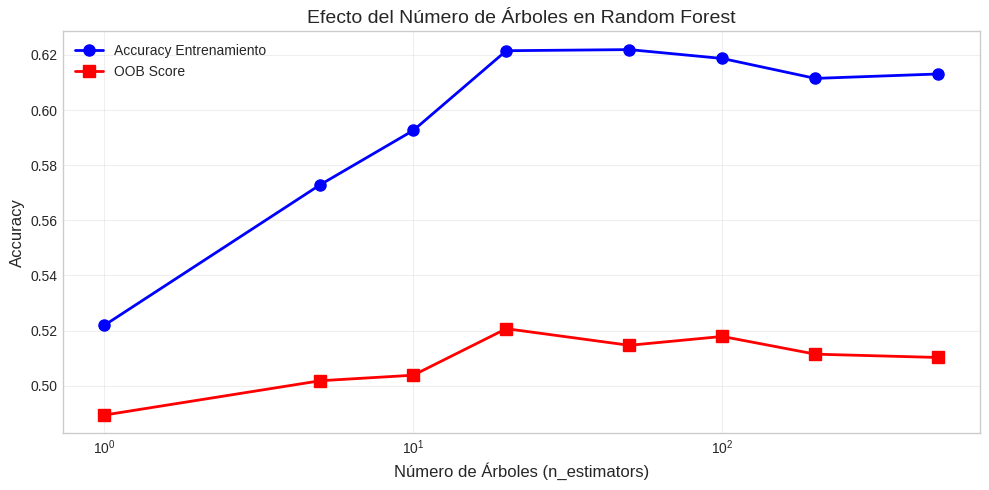


💡 Observaciones:
   • Con pocos árboles (1-5): Alta variabilidad
   • A partir de ~50-100 árboles: El OOB score se estabiliza
   • Más árboles NO causa sobreajuste (a diferencia de otros hiperparámetros)


In [ ]:
# ============================================================
# VISUALIZAR EFECTO DE n_estimators
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(n_arboles_lista, train_scores, 'b-o', label='Accuracy Entrenamiento', linewidth=2, markersize=8)
ax.plot(n_arboles_lista, oob_scores, 'r-s', label='OOB Score', linewidth=2, markersize=8)

ax.set_xlabel('Número de Árboles (n_estimators)', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Efecto del Número de Árboles en Random Forest', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.show()

print("\n💡 Observaciones:")
print("   • Con pocos árboles (1-5): Alta variabilidad")
print("   • A partir de ~50-100 árboles: El OOB score se estabiliza")
print("   • Más árboles NO causa sobreajuste (a diferencia de otros hiperparámetros)")

## 12. Aplicación: Sistema de Trading con Random Forest

In [ ]:
# ============================================================
# CREAR SISTEMA DE TRADING
# ============================================================

# Predicciones y probabilidades
df_clean['Pred_RF'] = rf.predict(X)
df_clean['Prob_RF'] = rf.predict_proba(X)[:, 1]  # Probabilidad de SUBE

# Estrategia:
# - Si predice SUBE (1) → Comprar (retorno = Target_Return)
# - Si predice BAJA (0) → Vender/corto (retorno = -Target_Return)
df_clean['Retorno_Sistema_RF'] = df_clean['Pred_RF'].map({1: 1, 0: -1}) * df_clean['Target_Return']

print("✅ Sistema de trading creado")
print(f"\n   Días predichos SUBE: {(df_clean['Pred_RF'] == 1).sum():,}")
print(f"   Días predichos BAJA: {(df_clean['Pred_RF'] == 0).sum():,}")

✅ Sistema de trading creado

   Días predichos SUBE: 1,667
   Días predichos BAJA: 822


In [ ]:
# ============================================================
# MÉTRICAS DEL SISTEMA DE TRADING
# ============================================================

# Retorno total
retorno_sistema = (1 + df_clean['Retorno_Sistema_RF']).prod() - 1
retorno_buyhold = (1 + df_clean['Target_Return']).prod() - 1

# Retorno anualizado (aproximado)
n_años = len(df_clean) / 252
ret_anual_sistema = (1 + retorno_sistema) ** (1/n_años) - 1
ret_anual_buyhold = (1 + retorno_buyhold) ** (1/n_años) - 1

print("=" * 60)
print("MÉTRICAS DEL SISTEMA DE TRADING (Random Forest)")
print("=" * 60)
print(f"\n{'Métrica':<30} {'Sistema RF':<15} {'Buy & Hold':<15}")
print("-" * 60)
print(f"{'Retorno Total':<30} {retorno_sistema:>14.2%} {retorno_buyhold:>14.2%}")
print(f"{'Retorno Anualizado':<30} {ret_anual_sistema:>14.2%} {ret_anual_buyhold:>14.2%}")
print("=" * 60)
print("\n⚠️ ADVERTENCIA: Resultados sobre datos de ENTRENAMIENTO.")
print("   NO reflejan rendimiento real. Ver Sesión 8 para evaluación correcta.")

MÉTRICAS DEL SISTEMA DE TRADING (Random Forest)

Métrica                        Sistema RF      Buy & Hold     
------------------------------------------------------------
Retorno Total                         533.10%         -9.77%
Retorno Anualizado                     20.54%         -1.04%

⚠️ ADVERTENCIA: Resultados sobre datos de ENTRENAMIENTO.
   NO reflejan rendimiento real. Ver Sesión 8 para evaluación correcta.


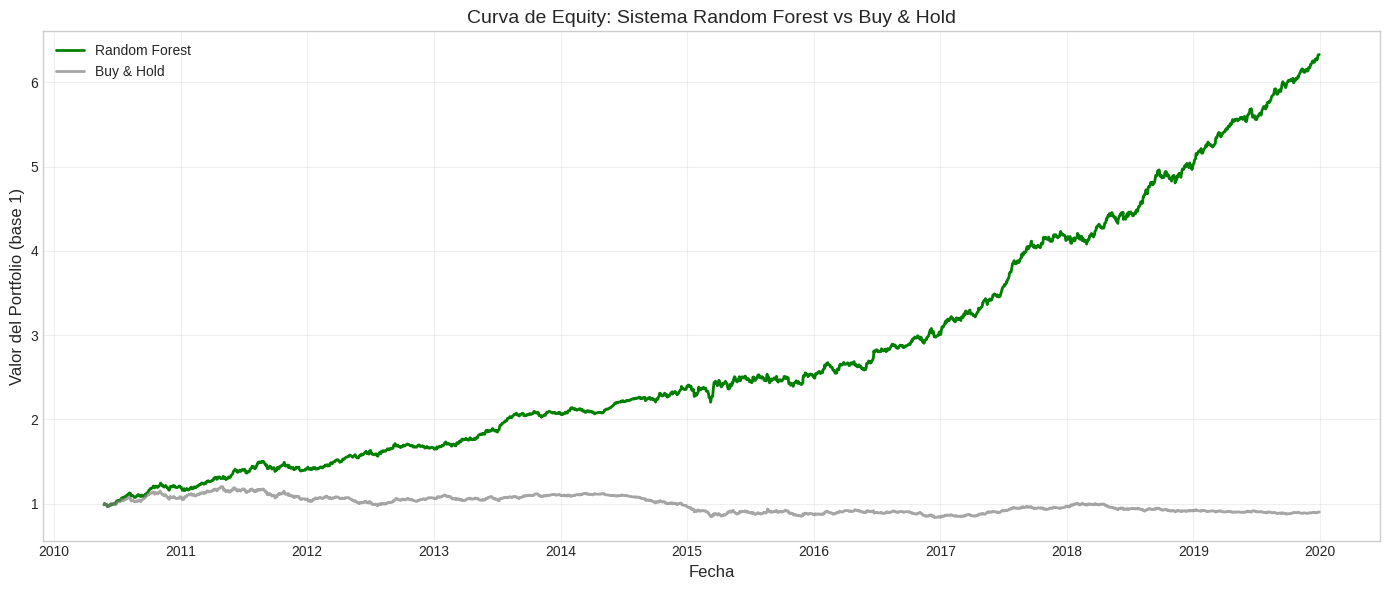


⚠️ ADVERTENCIA: Este resultado es sobre datos de ENTRENAMIENTO.
   NO refleja el rendimiento real que tendría el sistema.
   En Sesión 8 aprenderemos evaluación correcta (IS/OOS).


In [ ]:
# ============================================================
# CURVA DE EQUITY
# ============================================================

# Calcular curvas de equity
df_clean['Equity_RF'] = (1 + df_clean['Retorno_Sistema_RF']).cumprod()
df_clean['Equity_BuyHold'] = (1 + df_clean['Target_Return']).cumprod()

# Gráfico
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_clean.index, df_clean['Equity_RF'], label='Random Forest', linewidth=2, color='green')
ax.plot(df_clean.index, df_clean['Equity_BuyHold'], label='Buy & Hold', linewidth=2, color='gray', alpha=0.7)

ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Valor del Portfolio (base 1)', fontsize=12)
ax.set_title('Curva de Equity: Sistema Random Forest vs Buy & Hold', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n⚠️ ADVERTENCIA: Este resultado es sobre datos de ENTRENAMIENTO.")
print("   NO refleja el rendimiento real que tendría el sistema.")
print("   En Sesión 8 aprenderemos evaluación correcta (IS/OOS).")

## 13. Comparación: Random Forest vs Árbol Individual

In [ ]:
# ============================================================
# COMPARACIÓN: RANDOM FOREST vs ÁRBOL INDIVIDUAL
# ============================================================

# Entrenar árbol individual para comparar
arbol = DecisionTreeClassifier(max_depth=4, random_state=42)
arbol.fit(X, y)
pred_arbol = arbol.predict(X)
acc_arbol = accuracy_score(y, pred_arbol)

print("=" * 70)
print("COMPARACIÓN: RANDOM FOREST vs ÁRBOL DE DECISIÓN")
print("=" * 70)
print(f"\n{'Aspecto':<30} {'Árbol Individual':<20} {'Random Forest':<20}")
print("-" * 70)
print(f"{'Número de modelos':<30} {'1':<20} {'100 árboles':<20}")
print(f"{'Datos de entrenamiento':<30} {'Todos':<20} {'Bootstrap (~63%)':<20}")
print(f"{'Features por split':<30} {'Todas (4)':<20} {'Aleatorias (√4=2)':<20}")
print(f"{'Interpretabilidad':<30} {'Alta':<20} {'Media':<20}")
print(f"{'Varianza':<30} {'Alta':<20} {'Baja':<20}")
print(f"{'Riesgo sobreajuste':<30} {'Alto':<20} {'Medio':<20}")
print("-" * 70)
print(f"{'Accuracy (entrenamiento)':<30} {acc_arbol:<19.2%} {acc_train:<19.2%}")
print(f"{'OOB Score':<30} {'N/A':<20} {acc_oob:<19.2%}")
print("=" * 70)

print("\n💡 Observaciones:")
print(f"   • RF tiene accuracy similar en entrenamiento")
print(f"   • El OOB Score ({acc_oob:.2%}) es una estimación más realista")
print(f"   • RF es más ROBUSTO: menos sensible a pequeños cambios en datos")

COMPARACIÓN: RANDOM FOREST vs ÁRBOL DE DECISIÓN

Aspecto                        Árbol Individual     Random Forest       
----------------------------------------------------------------------
Número de modelos              1                    100 árboles         
Datos de entrenamiento         Todos                Bootstrap (~63%)    
Features por split             Todas (4)            Aleatorias (√4=2)   
Interpretabilidad              Alta                 Media               
Varianza                       Alta                 Baja                
Riesgo sobreajuste             Alto                 Medio               
----------------------------------------------------------------------
Accuracy (entrenamiento)       54.20%              61.87%             
OOB Score                      N/A                  51.79%             

💡 Observaciones:
   • RF tiene accuracy similar en entrenamiento
   • El OOB Score (51.79%) es una estimación más realista
   • RF es más ROBUSTO: menos s

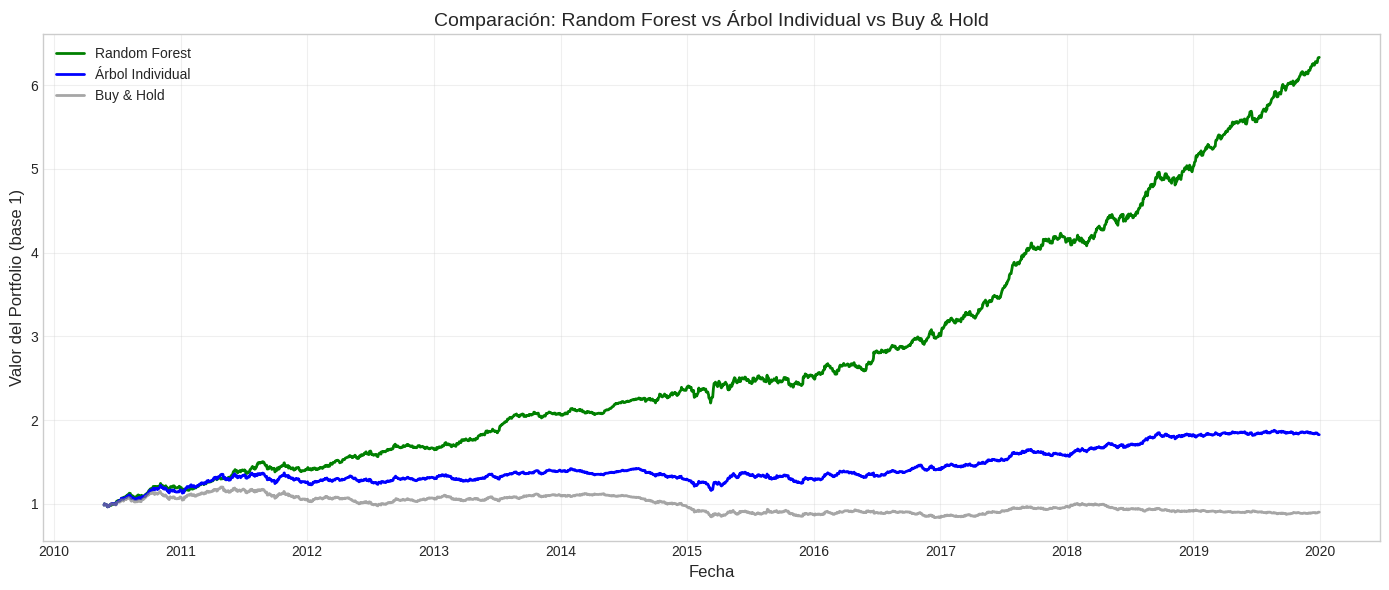

In [ ]:
# ============================================================
# COMPARAR CURVAS DE EQUITY: RF vs ÁRBOL vs BUY&HOLD
# ============================================================

# Sistema con árbol individual
df_clean['Pred_Arbol'] = arbol.predict(X)
df_clean['Retorno_Arbol'] = df_clean['Pred_Arbol'].map({1: 1, 0: -1}) * df_clean['Target_Return']
df_clean['Equity_Arbol'] = (1 + df_clean['Retorno_Arbol']).cumprod()

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_clean.index, df_clean['Equity_RF'], label='Random Forest', linewidth=2, color='green')
ax.plot(df_clean.index, df_clean['Equity_Arbol'], label='Árbol Individual', linewidth=2, color='blue')
ax.plot(df_clean.index, df_clean['Equity_BuyHold'], label='Buy & Hold', linewidth=2, color='gray', alpha=0.7)

ax.set_xlabel('Fecha', fontsize=12)
ax.set_ylabel('Valor del Portfolio (base 1)', fontsize=12)
ax.set_title('Comparación: Random Forest vs Árbol Individual vs Buy & Hold', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 14. Uso de Probabilidades para Filtrar Señales

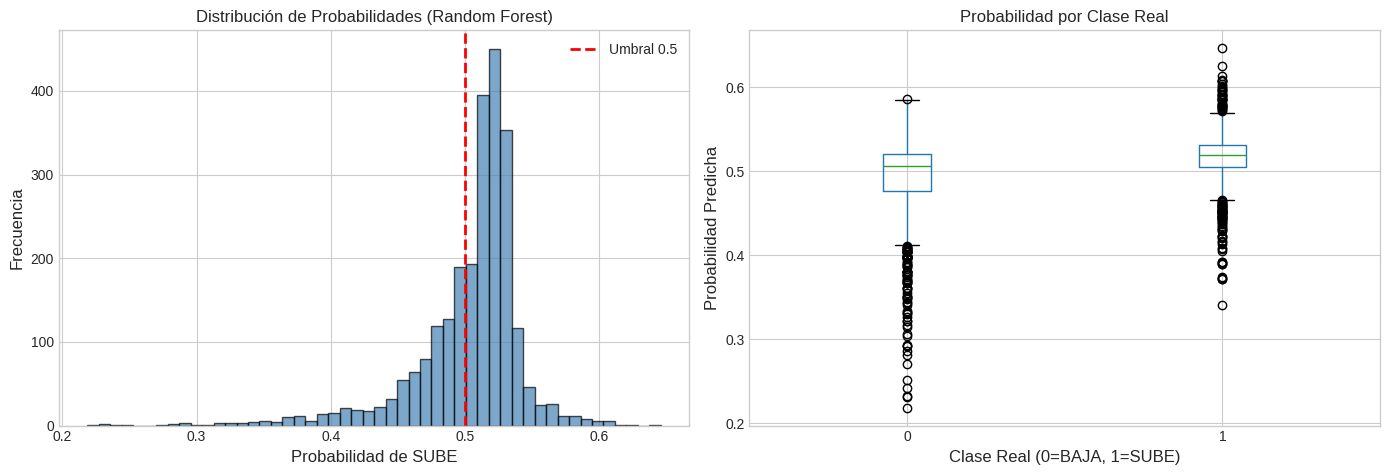


💡 Podemos usar las probabilidades para filtrar señales:
   • Solo operar cuando P(SUBE) > 0.6 o P(SUBE) < 0.4
   • Ignorar señales con probabilidad cercana a 0.5 (inciertas)


In [ ]:
# ============================================================
# DISTRIBUCIÓN DE PROBABILIDADES
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de probabilidades
axes[0].hist(df_clean['Prob_RF'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Umbral 0.5')
axes[0].set_xlabel('Probabilidad de SUBE', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Probabilidades (Random Forest)', fontsize=12)
axes[0].legend()

# Boxplot por clase real
df_clean.boxplot(column='Prob_RF', by='Target_Direccion', ax=axes[1])
axes[1].set_xlabel('Clase Real (0=BAJA, 1=SUBE)', fontsize=12)
axes[1].set_ylabel('Probabilidad Predicha', fontsize=12)
axes[1].set_title('Probabilidad por Clase Real', fontsize=12)
plt.suptitle('')  # Eliminar título automático

plt.tight_layout()
plt.show()

print("\n💡 Podemos usar las probabilidades para filtrar señales:")
print("   • Solo operar cuando P(SUBE) > 0.6 o P(SUBE) < 0.4")
print("   • Ignorar señales con probabilidad cercana a 0.5 (inciertas)")

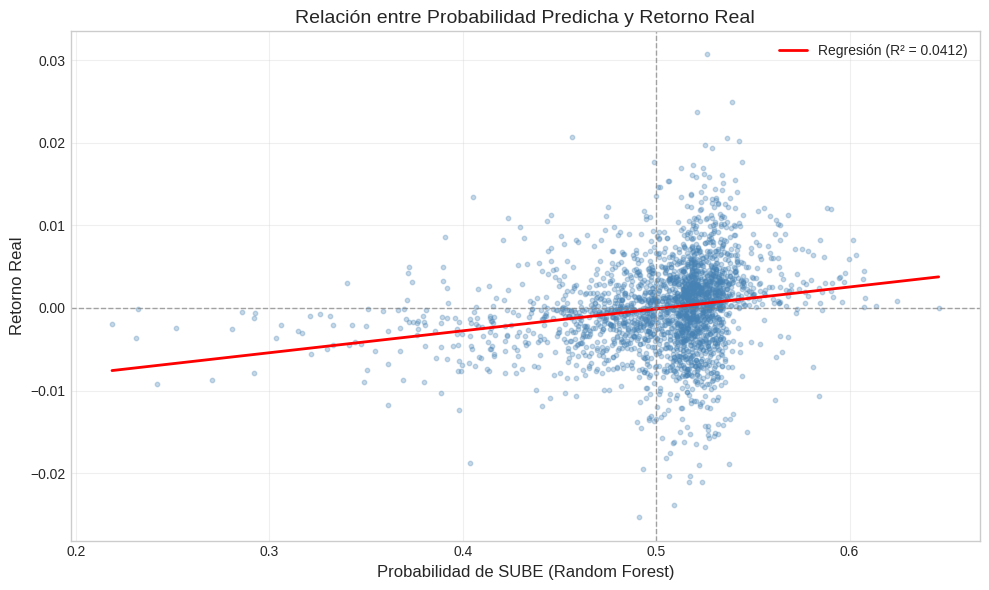


📊 Estadísticas de la regresión:
   Pendiente:     0.026525
   R²:            0.0412
   p-valor:       1.5593e-24

💡 Si el modelo tiene capacidad predictiva, la pendiente debería ser positiva:
   → Prob. alta → Retornos positivos
   → Prob. baja → Retornos negativos


In [ ]:
# ============================================================
# RELACIÓN ENTRE PROBABILIDAD Y RETORNO REAL
# ============================================================

from scipy import stats

fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
ax.scatter(df_clean['Prob_RF'], df_clean['Target_Return'],
           alpha=0.3, s=10, color='steelblue')

# Línea de regresión
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df_clean['Prob_RF'], df_clean['Target_Return'])
x_line = np.linspace(df_clean['Prob_RF'].min(), df_clean['Prob_RF'].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color='red', linewidth=2,
        label=f'Regresión (R² = {r_value**2:.4f})')

# Líneas de referencia
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7)

ax.set_xlabel('Probabilidad de SUBE (Random Forest)', fontsize=12)
ax.set_ylabel('Retorno Real', fontsize=12)
ax.set_title('Relación entre Probabilidad Predicha y Retorno Real', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Estadísticas de la regresión:")
print(f"   Pendiente:     {slope:.6f}")
print(f"   R²:            {r_value**2:.4f}")
print(f"   p-valor:       {p_value:.4e}")
print(f"\n💡 Si el modelo tiene capacidad predictiva, la pendiente debería ser positiva:")
print(f"   → Prob. alta → Retornos positivos")
print(f"   → Prob. baja → Retornos negativos")

In [ ]:
# ============================================================
# SISTEMA CON FILTRO DE CONFIANZA
# ============================================================

# Umbral de confianza
umbral = 0.55

# Señal filtrada: solo operar si probabilidad > umbral o < (1-umbral)
df_clean['Señal_Filtrada'] = 0  # Por defecto: no operar
df_clean.loc[df_clean['Prob_RF'] >= umbral, 'Señal_Filtrada'] = 1   # Comprar
df_clean.loc[df_clean['Prob_RF'] <= (1-umbral), 'Señal_Filtrada'] = -1  # Vender

# Contar operaciones
n_operar = (df_clean['Señal_Filtrada'] != 0).sum()
n_no_operar = (df_clean['Señal_Filtrada'] == 0).sum()

print(f"\nUmbral de confianza: {umbral}")
print(f"Días que operamos:    {n_operar:,} ({n_operar/len(df_clean):.1%})")
print(f"Días sin operar:      {n_no_operar:,} ({n_no_operar/len(df_clean):.1%})")

# Accuracy solo en días que operamos
df_opera = df_clean[df_clean['Señal_Filtrada'] != 0]
if len(df_opera) > 0:
    aciertos = ((df_opera['Señal_Filtrada'] == 1) & (df_opera['Target_Direccion'] == 1)) | \
               ((df_opera['Señal_Filtrada'] == -1) & (df_opera['Target_Direccion'] == 0))
    acc_filtrada = aciertos.sum() / len(df_opera)
    print(f"\nAccuracy (solo días que operamos): {acc_filtrada:.2%}")


Umbral de confianza: 0.55
Días que operamos:    314 (12.6%)
Días sin operar:      2,175 (87.4%)

Accuracy (solo días que operamos): 82.17%


## ⚠️ Advertencia Importante

```
ERROR METODOLÓGICO (que corregiremos en próximas sesiones)
═══════════════════════════════════════════════════════════════════

En esta sesión hemos cometido el MISMO error que en sesiones anteriores:

    ENTRENAMOS y EVALUAMOS con los MISMOS datos.

Aunque Random Forest es más robusto que un árbol individual:

    • El OOB Score es una mejor estimación que accuracy de entrenamiento
    • Pero NO sustituye una evaluación rigurosa Out-of-Sample
    • Las curvas de equity siguen siendo sobre datos de entrenamiento

En las próximas sesiones aprenderemos a evaluar correctamente:

    • Sesión 8: Partición In-Sample / Out-of-Sample
    • Sesión 9: Sobreoptimización y validación cruzada

Por ahora, el objetivo es entender CÓMO funciona Random Forest,
no crear un sistema de trading real.
```

## 📝 Nota: Ejercicio Evaluable (30%)

```
INFORMACIÓN IMPORTANTE
═══════════════════════════════════════════════════════════════════

Random Forest será la base del ejercicio práctico evaluable.

El ejercicio consistirá en:

    1. Aplicar Random Forest a un dataset financiero
    2. Experimentar con diferentes hiperparámetros
    3. Analizar la importancia de variables
    4. Evaluar el modelo correctamente (tras Sesión 8)

Se proporcionará un notebook con instrucciones detalladas
después de completar las sesiones de metodología de evaluación.

Fecha de entrega: Se comunicará en clase.
```

---

## Resumen de la Sesión

En esta sesión hemos aprendido:

✅ **Por qué ensamblar modelos:** Combinar modelos "débiles" → Modelo "fuerte"

✅ **Bagging (Bootstrap Aggregating):** Muestreo con reemplazo para crear diversidad

✅ **Random Forest = Bagging + Aleatoriedad en Features:** Mayor diversidad de árboles

✅ **Parámetros clave:** n_estimators, max_features, max_depth

✅ **OOB Score:** Evaluación "gratis" usando datos no vistos por cada árbol

✅ **Feature Importance:** Importancia promediada de 100 árboles (más estable)

✅ **Ventajas de RF:** Menor varianza, más robusto, menos sobreajuste

✅ **Uso de probabilidades:** Para filtrar señales por nivel de confianza

### Próxima Sesión

En la **Sesión 7 (29 de enero)** veremos **Selección de Variables**, donde aprenderemos:

- **Métodos de selección:** Filtro, Wrapper, Embedded
- **Importancia de variables:** Permutation importance, Drop-column importance
- **Reducir dimensionalidad:** Menos features → Modelos más simples y robustos

Esto será útil cuando tengamos MUCHAS features (como los 400+ indicadores que podemos calcular).